# EE 446 Homework 1 Programming Notebook

Use the **tinyml-arduino** Python environment that you set up for this class. In JupyterLab, select the kernel named **Python (tinyml-arduino)** before running this notebook.

Do not install or uninstall TensorFlow packages inside this notebook. The class environment already contains the required packages for this assignment, including TensorFlow, TensorFlow Model Optimization Toolkit, scikit-learn, NumPy, pandas, and JupyterLab.

This notebook contains the programming questions marked **[Pro]**. Complete each section by replacing the placeholder comments with your own code. Print the requested outputs so that your work can be graded directly from the notebook.


In [1]:
import sys
print(sys.executable)

/home/wadhwa19/ai/projects/tinyml-arduino/bin/python


In [2]:
import sys
!{sys.executable} -m pip install "tensorflow-model-optimization==0.8.0"


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import sys
!{sys.executable} -m pip install "keras==2.14.0"


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, r2_score

import tensorflow as tf
import tensorflow_model_optimization as tfmot

Sequential = tf.keras.Sequential
Dense = tf.keras.layers.Dense
LSTM = tf.keras.layers.LSTM
to_categorical = tf.keras.utils.to_categorical

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)

TensorFlow version: 2.14.1
TF-MOT version: 0.8.0



---

# Problem 1: DNN and Wine Classification (80 points)

This problem uses the Wine dataset available through scikit-learn. The dataset is loaded locally from the installed package, so no external data file is required.


In [5]:
# Load the Wine dataset from scikit-learn.
# This avoids requiring an external wine.data file.

wine = load_wine(as_frame=True)

feature_names = list(wine.feature_names)
df = wine.frame.copy()
df["Class"] = wine.target

# Reorder the columns so that the class label appears first.
df = df[["Class"] + feature_names]

# Number of classes
num_classes = df["Class"].nunique()
print("Number of classes:", num_classes)

# Number of features, excluding the class label
num_features = df.shape[1] - 1
print("Number of features:", num_features)

# Basic feature statistics
feature_stats = df.drop(columns=["Class"]).describe().T[["min", "max", "mean", "std"]]
print("\nFeature statistics:\n", feature_stats)

# Class distribution
class_counts = df["Class"].value_counts().sort_index()
print("\nClass distribution:\n", class_counts)


Number of classes: 3
Number of features: 13

Feature statistics:
                                  min      max        mean         std
alcohol                        11.03    14.83   13.000618    0.811827
malic_acid                      0.74     5.80    2.336348    1.117146
ash                             1.36     3.23    2.366517    0.274344
alcalinity_of_ash              10.60    30.00   19.494944    3.339564
magnesium                      70.00   162.00   99.741573   14.282484
total_phenols                   0.98     3.88    2.295112    0.625851
flavanoids                      0.34     5.08    2.029270    0.998859
nonflavanoid_phenols            0.13     0.66    0.361854    0.124453
proanthocyanins                 0.41     3.58    1.590899    0.572359
color_intensity                 1.28    13.00    5.058090    2.318286
hue                             0.48     1.71    0.957449    0.228572
od280/od315_of_diluted_wines    1.27     4.00    2.611685    0.709990
proline                 

## Problem 1 - Part (a)
### Base Model Training and Evaluation


In [6]:
# Step 1: Separate the feature matrix and class labels.
# - Assign the feature columns to variable X.
# - Assign the class labels to variable y.
# - The labels in this scikit-learn dataset are already zero-based: 0, 1, and 2.

# <-- Enter your code here <--#
X = df[feature_names].values
y = df["Class"].values

In [7]:
# Step 2: Perform a train-test split (70% train, 30% test) using random_state=42

# <-- Enter your code here <--#
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Step 3: Use StandardScaler to normalize the features
# - Fit on X_train and transform both X_train and X_test

# <-- Enter your code here <--#
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# Step 4: Use one-hot encoding for y_train and y_test.
# - Use tf.keras.utils.to_categorical.
# - Use num_classes=num_classes to make the output shape explicit.

# <-- Enter your code here <--#
y_train_en = to_categorical(y_train, num_classes=num_classes)
y_test_en = to_categorical(y_test, num_classes=num_classes)

In [11]:
# Step 5: Define a Sequential model with the following architecture:
# - Dense(64, activation='relu')
# - Dense(32, activation='relu')
# - Dense(num_classes, activation='softmax')
# Make sure the first Dense layer receives the correct input shape.

# <-- Enter your code here <--#
model = tf.keras.Sequential([
            tf.keras.layers.Dense(64,activation = 'relu' , input_shape =(num_features,)),
            tf.keras.layers.Dense(32,activation = 'relu'),
            tf.keras.layers.Dense(num_classes,activation = 'softmax')
    ])


In [13]:
# Step 6: Compile using Adam optimizer, categorical_crossentropy loss, and accuracy metric
# - Train for 20 epochs with batch_size=8 and validation_split=0.2

# <-- Enter your code here <--#
model.compile(
           optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
           loss='categorical_crossentropy',
           metrics=['accuracy']
       )
history = model.fit(X_train, y_train_en, epochs=20, batch_size=8, validation_split=0.2)

Epoch 1/20
13/13 [==============================] - 1s 23ms/step - loss: 65.9599 - accuracy: 0.3636 - val_loss: 7.6827 - val_accuracy: 0.4000
Epoch 2/20
13/13 [==============================] - 0s 11ms/step - loss: 16.4828 - accuracy: 0.3232 - val_loss: 12.4992 - val_accuracy: 0.5200
Epoch 3/20
13/13 [==============================] - 0s 7ms/step - loss: 8.7755 - accuracy: 0.4343 - val_loss: 3.7697 - val_accuracy: 0.4800
Epoch 4/20
13/13 [==============================] - 0s 6ms/step - loss: 2.6494 - accuracy: 0.4747 - val_loss: 3.8124 - val_accuracy: 0.4400
Epoch 5/20
13/13 [==============================] - 0s 6ms/step - loss: 2.3205 - accuracy: 0.5455 - val_loss: 2.2443 - val_accuracy: 0.4800
Epoch 6/20
13/13 [==============================] - 0s 7ms/step - loss: 2.9444 - accuracy: 0.4646 - val_loss: 1.8049 - val_accuracy: 0.4800
Epoch 7/20
13/13 [==============================] - 0s 6ms/step - loss: 2.1675 - accuracy: 0.5758 - val_loss: 1.6939 - val_accuracy: 0.4400
Epoch 8/20
13/1

2/2 [==============================] - 0s 6ms/step
Test Accuracy:  0.9074

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        19
           1       0.90      0.90      0.90        21
           2       0.80      0.86      0.83        14

    accuracy                           0.91        54
   macro avg       0.90      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54



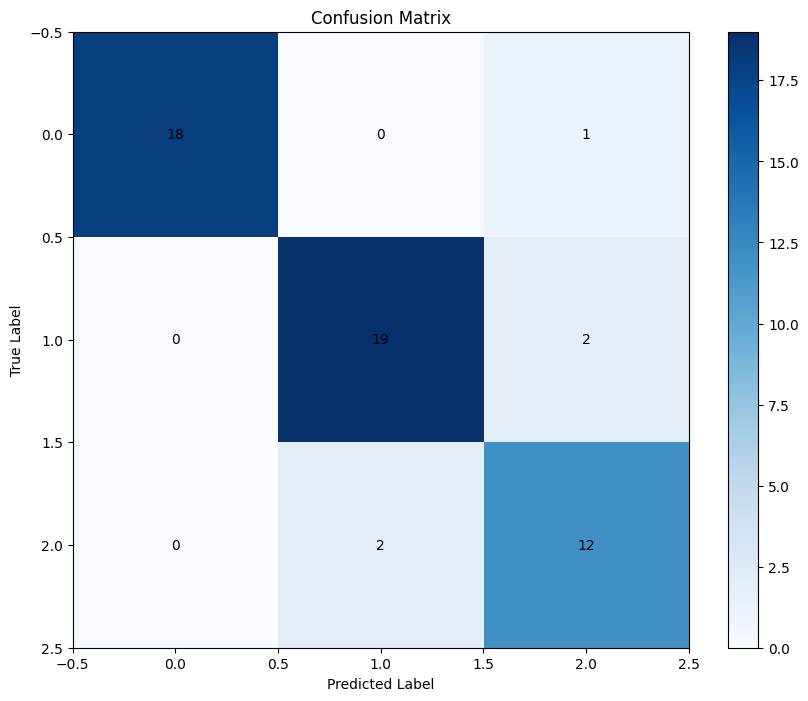

In [14]:
# Step 7: Evaluate the model on test data and print:
# - Accuracy
# - Classification report
# - Confusion matrix

# <-- Enter your code here <--#

y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob,axis=1)
test_accuracy = np.mean(y_pred==y_test)
print(f"Test Accuracy: {test_accuracy: .4f}")

print("\nClassification Report:")
print(classification_report(y_test,y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues')
plt.colorbar()

# Adding number annotations 
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [37]:
model.save("baseline_model.keras")
print(f"Original Keras model size: {os.path.getsize('baseline_model.keras') / 1024.0:.2f} KB")

Original Keras model size: 61.81 KB


In [18]:
# Step 8: Convert the trained model to TFLite format and save it as "model_base.tflite"
# - Print the file size in kilobytes

# <-- Enter your code here <--#
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB
    
def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()


tflite_fp32 = convert_to_tflite_fp32(model)
size_fp32 = save_binary_model(tflite_fp32, "model_base.tflite")
print(f"FP32 TFLite model size: {size_fp32:.2f} KB")


INFO:tensorflow:Assets written to: /tmp/tmpulyazq93/assets


INFO:tensorflow:Assets written to: /tmp/tmpulyazq93/assets


FP32 TFLite model size: 14.07 KB


2026-05-19 16:06:07.245832: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 16:06:07.245927: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 16:06:07.246231: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpulyazq93
2026-05-19 16:06:07.247853: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 16:06:07.247881: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpulyazq93
2026-05-19 16:06:07.251682: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-19 16:06:07.320257: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpulyazq93
2026-05-19 16:06:07.337464: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 91234 m

## Problem 1 - Part (b)

### Quantization (int8, float16, dynamic range)


In [22]:
def representative_data_gen(X_reference, num_samples=100):
    """Create a representative dataset generator for full integer quantization."""
    max_samples = min(num_samples, len(X_reference))
    for i in range(max_samples):
        yield [X_reference[i:i + 1].astype(np.float32)]


def quantize_and_evaluate(model, X_test, y_test_cat, quant_type, filename):
    """Convert a Keras model to TFLite, evaluate it, and report model size.

    Parameters
    ----------
    model : tf.keras.Model
        Trained Keras model.
    X_test : np.ndarray
        Test features after the same preprocessing used for training.
    y_test_cat : np.ndarray
        One-hot encoded test labels.
    quant_type : str
        One of: 'int8', 'float16', or 'dynamic'.
    filename : str
        Output TFLite filename.
    """

    # Create the TFLite converter from the trained Keras model.
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    # Step 1: Apply quantization settings.
    if quant_type == 'int8':
        # (a) Enable default optimizations.
        # (b) Provide representative_data_gen(X_train_scaled).
        # (c) Set supported_ops to TFLITE_BUILTINS_INT8.
        # (d) Set inference_input_type and inference_output_type to tf.int8.

        # <-- Enter your code here <--#
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = lambda: representative_data_gen(X_train)
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8


    elif quant_type == 'float16':
        # (a) Enable default optimizations.
        # (b) Set supported_types to [tf.float16].

        # <-- Enter your code here <--#
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]

    elif quant_type == 'dynamic':
        # (a) Enable default optimizations.

        # <-- Enter your code here <--#
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]

    else:
        raise ValueError("quant_type must be one of: 'int8', 'float16', or 'dynamic'.")

    # Step 2: Convert the model and save it to the provided filename.

    # <-- Enter your code here <--#
    tflite_model = converter.convert()
    with open(filename, "wb") as f:
        f.write(tflite_model)
    # Step 3: Run TFLite inference.
    # Complete the following:
    # - Use tf.lite.Interpreter to load the TFLite model.
    # - Allocate tensors.
    # - Get input and output tensor details.
    # - If the input is quantized, quantize each test sample using scale and zero point.
    # - If the output is quantized, dequantize the prediction using scale and zero point.
    # - Collect predictions into y_pred using np.argmax.
    # - Compare with y_true = np.argmax(y_test_cat, axis=1).

    # <-- Enter your code here for TFLite inference <--#
    interpreter = tf.lite.Interpreter(model_path=filename)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_tensor_details()[0] if hasattr(interpreter, 'get_input_tensor_details') else interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    input_details = interpreter.get_input_details()[0]

    input_scale, input_zero_point = input_details['quantization']
    output_scale, output_zero_point = output_details['quantization']

    y_pred = []
    for i in range(len(X_test)):
        sample = X_test[i:i + 1].astype(np.float32)

        # Quantize input if needed
        if input_details['dtype'] == np.int8:
            sample = (sample / input_scale + input_zero_point).astype(np.int8)
        elif input_details['dtype'] == np.uint8:
            sample = (sample / input_scale + input_zero_point).astype(np.uint8)

        interpreter.set_tensor(input_details['index'], sample)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details['index'])[0]

        # Dequantize output if needed
        if output_details['dtype'] == np.int8 or output_details['dtype'] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output))
    y_pred = np.array(y_pred)
    y_true = np.argmax(y_test_cat, axis=1)
    
    # Step 4: Report results.
    

    # <-- Enter your code here: print classification_report and confusion_matrix <--#
    print(f"\n{quant_type.upper()} TFLite model size: {os.path.getsize(filename) / 1024.0:.2f} KB")
    print(f"Accuracy: {np.mean(y_pred == y_true):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))


In [23]:
# Step 5: Use the function above to create and evaluate three quantized models:
# - 'int8' saved as 'model_int8.tflite'
# - 'float16' saved as 'model_float16.tflite'
# - 'dynamic' saved as 'model_dynamic.tflite'

# <-- Enter your code here <--#
quantize_and_evaluate(model, X_test, y_test_en, 'int8', 'model_int8.tflite')
quantize_and_evaluate(model, X_test, y_test_en, 'float16', 'model_float16.tflite')
quantize_and_evaluate(model, X_test, y_test_en, 'dynamic', 'model_dynamic.tflite')

INFO:tensorflow:Assets written to: /tmp/tmp54jzwcfw/assets


INFO:tensorflow:Assets written to: /tmp/tmp54jzwcfw/assets
/home/wadhwa19/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-19 16:20:10.540441: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 16:20:10.540523: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 16:20:10.540790: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp54jzwcfw
2026-05-19 16:20:10.542126: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 16:20:10.542146: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp54jzwcfw
2026-05-19 16:20:10.547107: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.



INT8 TFLite model size: 5.74 KB
Accuracy: 0.6481

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.79      0.88        19
           1       0.54      0.95      0.69        21
           2       0.00      0.00      0.00        14

    accuracy                           0.65        54
   macro avg       0.51      0.58      0.52        54
weighted avg       0.56      0.65      0.58        54

Confusion Matrix:
[[15  3  1]
 [ 0 20  1]
 [ 0 14  0]]
INFO:tensorflow:Assets written to: /tmp/tmpg4j_8wfp/assets


INFO:tensorflow:Assets written to: /tmp/tmpg4j_8wfp/assets
2026-05-19 16:20:11.502204: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 16:20:11.502279: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 16:20:11.502479: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpg4j_8wfp
2026-05-19 16:20:11.503223: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 16:20:11.503235: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpg4j_8wfp
2026-05-19 16:20:11.505608: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-19 16:20:11.555006: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpg4j_8wfp
2026-05-19 16:20:11.569959: I tensorflow/cc/saved_model/loader.cc:316] SavedModel


FLOAT16 TFLite model size: 8.95 KB
Accuracy: 0.9074

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        19
           1       0.86      0.90      0.88        21
           2       0.86      0.86      0.86        14

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54

Confusion Matrix:
[[18  1  0]
 [ 0 19  2]
 [ 0  2 12]]
INFO:tensorflow:Assets written to: /tmp/tmpod14cz5i/assets


INFO:tensorflow:Assets written to: /tmp/tmpod14cz5i/assets



DYNAMIC TFLite model size: 8.95 KB
Accuracy: 0.9074

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        19
           1       0.86      0.90      0.88        21
           2       0.86      0.86      0.86        14

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54

Confusion Matrix:
[[18  1  0]
 [ 0 19  2]
 [ 0  2 12]]


2026-05-19 16:20:12.379312: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 16:20:12.379387: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 16:20:12.379605: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpod14cz5i
2026-05-19 16:20:12.380851: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 16:20:12.380881: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpod14cz5i
2026-05-19 16:20:12.384908: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-19 16:20:12.443179: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpod14cz5i
2026-05-19 16:20:12.458071: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 78467 m

## Problem 1 - Part (c)

### Pruning

In [24]:
# Step 1: Define a pruning schedule using tfmot.sparsity.keras.PolynomialDecay
# HINT:
# - Use initial_sparsity = 0.5 and final_sparsity = 0.7
# - Set end_step to total training steps (approx. dataset_size / batch_size * epochs)

# <-- Enter your code here <--#
batch_size = 8
epochs = 20
end_step = int(len(X_train) / batch_size) * epochs

pruning_schedule = tfmot.sparsity.keras.PolynomialDecay(
    initial_sparsity=0.5,
    final_sparsity=0.7,
    begin_step=0,
    end_step=end_step
)

In [25]:
# Step 2: Build a Sequential model with 3 pruned Dense layers:
# - Dense(64, relu)
# - Dense(32, relu)
# - Dense(3, softmax)
# Make sure each Dense layer is wrapped with prune_low_magnitude()

# <-- Enter your code here <--#
pruned_model = tf.keras.Sequential([
    tfmot.sparsity.keras.prune_low_magnitude(
        tf.keras.layers.Dense(64, activation='relu', input_shape=(num_features,)),
        pruning_schedule=pruning_schedule
    ),
    tfmot.sparsity.keras.prune_low_magnitude(
        tf.keras.layers.Dense(32, activation='relu'),
        pruning_schedule=pruning_schedule
    ),
    tfmot.sparsity.keras.prune_low_magnitude(
        tf.keras.layers.Dense(num_classes, activation='softmax'),
        pruning_schedule=pruning_schedule
    )
])

In [27]:
# Step 3: Compile the model with categorical_crossentropy and accuracy
# - Train for 10 epochs with batch_size=8 and validation_split=0.2
# - Add tfmot.sparsity.keras.UpdatePruningStep() to the callbacks list

# <-- Enter your code here <--#
pruned_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

pruned_history = pruned_model.fit(
    X_train, y_train_en,
    epochs=10,
    batch_size=8,
    validation_split=0.2,
    callbacks=[tfmot.sparsity.keras.UpdatePruningStep()]
)

Epoch 1/10
13/13 [==============================] - 4s 38ms/step - loss: 11.1672 - accuracy: 0.4141 - val_loss: 1.6279 - val_accuracy: 0.6800
Epoch 2/10
13/13 [==============================] - 0s 13ms/step - loss: 3.0969 - accuracy: 0.6465 - val_loss: 2.8596 - val_accuracy: 0.4800
Epoch 3/10
13/13 [==============================] - 0s 11ms/step - loss: 1.5634 - accuracy: 0.5556 - val_loss: 2.0852 - val_accuracy: 0.6400
Epoch 4/10
13/13 [==============================] - 0s 14ms/step - loss: 2.6350 - accuracy: 0.5152 - val_loss: 4.2248 - val_accuracy: 0.6800
Epoch 5/10
13/13 [==============================] - 0s 13ms/step - loss: 2.8303 - accuracy: 0.5960 - val_loss: 1.1614 - val_accuracy: 0.8400
Epoch 6/10
13/13 [==============================] - 0s 16ms/step - loss: 1.6069 - accuracy: 0.6364 - val_loss: 0.8592 - val_accuracy: 0.8000
Epoch 7/10
13/13 [==============================] - 0s 13ms/step - loss: 1.3195 - accuracy: 0.6263 - val_loss: 1.4620 - val_accuracy: 0.6400
Epoch 8/10
1

In [28]:
# Step 4: Remove pruning wrappers using tfmot.sparsity.keras.strip_pruning().
# Then convert the stripped model to TFLite and save it as "model_pruned.tflite".
# Print the final file size in KB.

# Important: converting the unstripped pruned model can keep extra pruning variables
# and make the saved model larger than expected.

# <-- Enter your code here <--#
stripped_model = tfmot.sparsity.keras.strip_pruning(pruned_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
tflite_pruned = converter.convert()

with open("model_pruned.tflite", "wb") as f:
    f.write(tflite_pruned)

size_pruned = os.path.getsize("model_pruned.tflite") / 1024.0
print(f"Pruned TFLite model size: {size_pruned:.2f} KB")

INFO:tensorflow:Assets written to: /tmp/tmpyprg8q0w/assets


INFO:tensorflow:Assets written to: /tmp/tmpyprg8q0w/assets


Pruned TFLite model size: 14.14 KB


2026-05-19 18:56:59.871885: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 18:56:59.872032: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 18:56:59.872486: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpyprg8q0w
2026-05-19 18:56:59.873722: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 18:56:59.873773: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpyprg8q0w
2026-05-19 18:56:59.876466: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-19 18:56:59.902363: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpyprg8q0w
2026-05-19 18:56:59.913829: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 41369 m

In [29]:
# Step 5: Evaluate using the stripped model
# - Use np.argmax for predictions
# - Print classification_report and confusion_matrix

# <-- Enter your code here <--#
y_prob_pruned = stripped_model.predict(X_test)
y_pred_pruned = np.argmax(y_prob_pruned, axis=1)

print(f"Pruned Model Accuracy: {np.mean(y_pred_pruned == y_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pruned))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_pruned))

2/2 [==============================] - 0s 8ms/step
Pruned Model Accuracy: 0.5556

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.84      0.91        19
           1       0.40      0.10      0.15        21
           2       0.36      0.86      0.51        14

    accuracy                           0.56        54
   macro avg       0.59      0.60      0.53        54
weighted avg       0.60      0.56      0.51        54

Confusion Matrix:
[[16  1  2]
 [ 0  2 19]
 [ 0  2 12]]


## Problem 1 - Part (d)

### Knowledge Distillation

In [30]:
# Step 1: Define a Sequential model for Student with:
# - Dense(32, relu)
# - Dense(16, relu)
# - Dense(3, softmax)

# <-- Enter your code here <--#
student_model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(num_features,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

In [31]:
# Step 2: Use model.predict() on X_train_scaled to obtain teacher soft labels

# <-- Enter your code here <--#
teacher_soft_labels = model.predict(X_train)

4/4 [==============================] - 0s 11ms/step


In [33]:
# Step 3:
# (a) Concatenate hard (y_train_cat) and soft (teacher_preds_soft) labels along axis=1
#     to create a combined label for distillation
# (b) Define a custom distillation_loss() function that:
#     - Splits y_true_combined into y_true_hard and y_true_soft
#     - Computes two losses (both using categorical_crossentropy)
#     - Combines them with a weight factor alpha = 0.5

# Hint: Use slicing [:, :3] and [:, 3:] to split the combined labels

# <-- Enter your code here <--#
y_train_combined = np.concatenate([y_train_en, teacher_soft_labels], axis=1)
def distillation_loss(y_true_combined, y_pred):

    # <-- Enter your code here: implement hard/soft label separation and weighted loss <--#
    alpha = 0.5
    y_true_hard = y_true_combined[:, :3]
    y_true_soft = y_true_combined[:, 3:]
    
    hard_loss = tf.keras.losses.categorical_crossentropy(y_true_hard, y_pred)
    soft_loss = tf.keras.losses.categorical_crossentropy(y_true_soft, y_pred)
    
    return alpha * hard_loss + (1 - alpha) * soft_loss

In [34]:
# Step 4: Compile the student model with Adam optimizer and distillation_loss
# - Train for 10 epochs, batch_size=8, validation_split=0.2

# <-- Enter your code here <--#
student_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=distillation_loss,
    metrics=['accuracy']
)

student_history = student_model.fit(
    X_train, y_train_combined,
    epochs=10,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/10
13/13 [==============================] - 2s 37ms/step - loss: 70.4859 - accuracy: 0.3131 - val_loss: 37.5834 - val_accuracy: 0.2800
Epoch 2/10
13/13 [==============================] - 0s 11ms/step - loss: 22.4402 - accuracy: 0.3737 - val_loss: 18.5558 - val_accuracy: 0.4400
Epoch 3/10
13/13 [==============================] - 0s 9ms/step - loss: 12.0518 - accuracy: 0.3939 - val_loss: 10.9580 - val_accuracy: 0.2800
Epoch 4/10
13/13 [==============================] - 0s 12ms/step - loss: 5.9476 - accuracy: 0.3333 - val_loss: 4.5372 - val_accuracy: 0.2800
Epoch 5/10
13/13 [==============================] - 0s 12ms/step - loss: 4.1566 - accuracy: 0.3636 - val_loss: 1.5432 - val_accuracy: 0.4000
Epoch 6/10
13/13 [==============================] - 0s 8ms/step - loss: 2.7226 - accuracy: 0.5354 - val_loss: 1.8635 - val_accuracy: 0.6400
Epoch 7/10
13/13 [==============================] - 0s 9ms/step - loss: 1.3467 - accuracy: 0.4747 - val_loss: 1.1751 - val_accuracy: 0.4400
Epoch 8/10

In [35]:
# Step 5: Convert the student model to TFLite.
# - Save it as "model_kd.tflite".
# - Print the file size in KB.

# <-- Enter your code here <--#
converter = tf.lite.TFLiteConverter.from_keras_model(student_model)
tflite_kd = converter.convert()

with open("model_kd.tflite", "wb") as f:
    f.write(tflite_kd)

size_kd = os.path.getsize("model_kd.tflite") / 1024.0
print(f"Knowledge Distillation TFLite model size: {size_kd:.2f} KB")

INFO:tensorflow:Assets written to: /tmp/tmprrr5nfrm/assets


INFO:tensorflow:Assets written to: /tmp/tmprrr5nfrm/assets


Knowledge Distillation TFLite model size: 6.10 KB


2026-05-19 18:59:47.897466: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 18:59:47.897555: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 18:59:47.898146: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmprrr5nfrm
2026-05-19 18:59:47.899652: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 18:59:47.899682: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmprrr5nfrm
2026-05-19 18:59:47.903302: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-19 18:59:47.954855: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmprrr5nfrm
2026-05-19 18:59:47.968590: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 70468 m

In [36]:
# Step 6: Use student_model.predict() to obtain predictions on X_test_scaled
# - Print classification_report and confusion_matrix

# <-- Enter your code here <--#
y_prob_kd = student_model.predict(X_test)
y_pred_kd = np.argmax(y_prob_kd, axis=1)

print(f"Student Model Accuracy: {np.mean(y_pred_kd == y_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_kd))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_kd))

2/2 [==============================] - 0s 6ms/step
Student Model Accuracy: 0.6852

Classification Report:
              precision    recall  f1-score   support

           0       0.56      1.00      0.72        19
           1       0.89      0.38      0.53        21
           2       0.91      0.71      0.80        14

    accuracy                           0.69        54
   macro avg       0.79      0.70      0.68        54
weighted avg       0.78      0.69      0.67        54

Confusion Matrix:
[[19  0  0]
 [12  8  1]
 [ 3  1 10]]


## Problem 1 - Part (e)

### Possibility of Further Model Size Reduction

Can you **further reduce the model size** beyond the smallest model obtained in parts **(b)**, **(c)**, or **(d)**, **without sacrificing significant classification performance**?

Your task is to:

1. **Analyze and compare** the results from previous parts: Which model had the smallest size? Which performed best?

2. **Propose a strategy** that combines or enhances techniques learned so far.

3. **Implement** your proposed solution.

4. **Evaluate** the resulting model using both:
   - TFLite model size (in KB)
   - Classification performance (accuracy and report)

5. **Justify your results:**
   - If further size reduction is **not** possible without major loss of accuracy, explain why.
   - If you succeed in reducing the size **further**, highlight what change made the biggest difference.


### **Note:** If this part includes any code, please include it below. The related discussion should be submitted as part of your PDF that contains answers to all [Dis] questions in this assignment.


In [45]:
# Strategy: Light Pruning (30%) + Float16 Quantization

# Build and train a lightly pruned model 
light_schedule = tfmot.sparsity.keras.PolynomialDecay(
    initial_sparsity=0.1,
    final_sparsity=0.3,
    begin_step=0,
    end_step=int(len(X_train) / 8) * 20
)

pruned_model_v2 = tf.keras.Sequential([
    tfmot.sparsity.keras.prune_low_magnitude(
        tf.keras.layers.Dense(64, activation='relu', input_shape=(num_features,)),
        pruning_schedule=light_schedule
    ),
    tfmot.sparsity.keras.prune_low_magnitude(
        tf.keras.layers.Dense(32, activation='relu'),
        pruning_schedule=light_schedule
    ),
    tfmot.sparsity.keras.prune_low_magnitude(
        tf.keras.layers.Dense(num_classes, activation='softmax'),
        pruning_schedule=light_schedule
    )
])

pruned_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

pruned_model_v2.fit(
    X_train, y_train_en,
    epochs=20,
    batch_size=8,
    validation_split=0.2,
    callbacks=[tfmot.sparsity.keras.UpdatePruningStep()]
)

# Strip pruning wrappers 
stripped_model_v2 = tfmot.sparsity.keras.strip_pruning(pruned_model_v2)

# Apply Float16 quantization
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model_v2)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_pruned_f16 = converter.convert()
with open("model_pruned_f16.tflite", "wb") as f:
    f.write(tflite_pruned_f16)

size_pruned_f16 = os.path.getsize("model_pruned_f16.tflite") / 1024.0

#  Evaluation
interpreter = tf.lite.Interpreter(model_path="model_pruned_f16.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

y_pred_pf16 = []
for i in range(len(X_test)):
    sample = X_test[i:i + 1].astype(np.float32)
    interpreter.set_tensor(input_details['index'], sample)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details['index'])[0]
    y_pred_pf16.append(np.argmax(output))

y_pred_pf16 = np.array(y_pred_pf16)


print(" Pruning 30% + Float16 Quantization")

print(f"Model size: {size_pruned_f16:.2f} KB")
print(f"Accuracy: {np.mean(y_pred_pf16 == y_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pf16))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_pf16))

# Comparison 

print("SIZE COMPARISON")

print(f"Baseline FP32 TFLite:        {os.path.getsize('model_base.tflite')/1024:.2f} KB")
print(f"Float16 only:                {os.path.getsize('model_float16.tflite')/1024:.2f} KB")
print(f"Pruned only (FP32):          {os.path.getsize('model_pruned.tflite')/1024:.2f} KB")
print(f"Light Pruning + Float16:     {size_pruned_f16:.2f} KB")

Epoch 1/20
13/13 [==============================] - 1s 13ms/step - loss: 6.8489 - accuracy: 0.3939 - val_loss: 4.4972 - val_accuracy: 0.4000
Epoch 2/20
13/13 [==============================] - 0s 4ms/step - loss: 3.5803 - accuracy: 0.4242 - val_loss: 1.2355 - val_accuracy: 0.4400
Epoch 3/20
13/13 [==============================] - 0s 5ms/step - loss: 2.4392 - accuracy: 0.5455 - val_loss: 0.8004 - val_accuracy: 0.6800
Epoch 4/20
13/13 [==============================] - 0s 4ms/step - loss: 1.2945 - accuracy: 0.5253 - val_loss: 0.6385 - val_accuracy: 0.8400
Epoch 5/20
13/13 [==============================] - 0s 5ms/step - loss: 0.9618 - accuracy: 0.5758 - val_loss: 1.4493 - val_accuracy: 0.6000
Epoch 6/20
13/13 [==============================] - 0s 5ms/step - loss: 1.2590 - accuracy: 0.6263 - val_loss: 0.9226 - val_accuracy: 0.6000
Epoch 7/20
13/13 [==============================] - 0s 5ms/step - loss: 1.2983 - accuracy: 0.5859 - val_loss: 1.2082 - val_accuracy: 0.6800
Epoch 8/20
13/13 [=

INFO:tensorflow:Assets written to: /tmp/tmpgf3ajly4/assets


 Pruning 30% + Float16 Quantization
Model size: 9.09 KB
Accuracy: 0.6481

Classification Report:
              precision    recall  f1-score   support

           0       0.68      1.00      0.81        19
           1       0.62      0.76      0.68        21
           2       0.00      0.00      0.00        14

    accuracy                           0.65        54
   macro avg       0.43      0.59      0.50        54
weighted avg       0.48      0.65      0.55        54

Confusion Matrix:
[[19  0  0]
 [ 5 16  0]
 [ 4 10  0]]
SIZE COMPARISON
Baseline FP32 TFLite:        14.07 KB
Float16 only:                8.95 KB
Pruned only (FP32):          14.14 KB
Light Pruning + Float16:     9.09 KB


2026-05-19 22:10:48.539376: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 22:10:48.539436: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 22:10:48.539578: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpgf3ajly4
2026-05-19 22:10:48.539995: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 22:10:48.540012: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpgf3ajly4
2026-05-19 22:10:48.541147: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-19 22:10:48.550777: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpgf3ajly4
2026-05-19 22:10:48.554865: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 15287 m

# Problem 2: Exploring Edge Impulse (20 points)


### Note

Problem 2 consists entirely of discussion questions. Submit your responses in the same PDF file that contains answers to the other **[Dis]** questions in this assignment.

Before submission, make sure this notebook runs with the **Python (tinyml-arduino)** kernel and that all requested outputs are visible. Host this notebook and your discussion PDF in your public GitHub repository, then submit the repository link through Canvas.
